# Analisis Sampel 1, Motif Utama

In [116]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [117]:
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from utils import *

array([  0, 255], dtype=uint8)

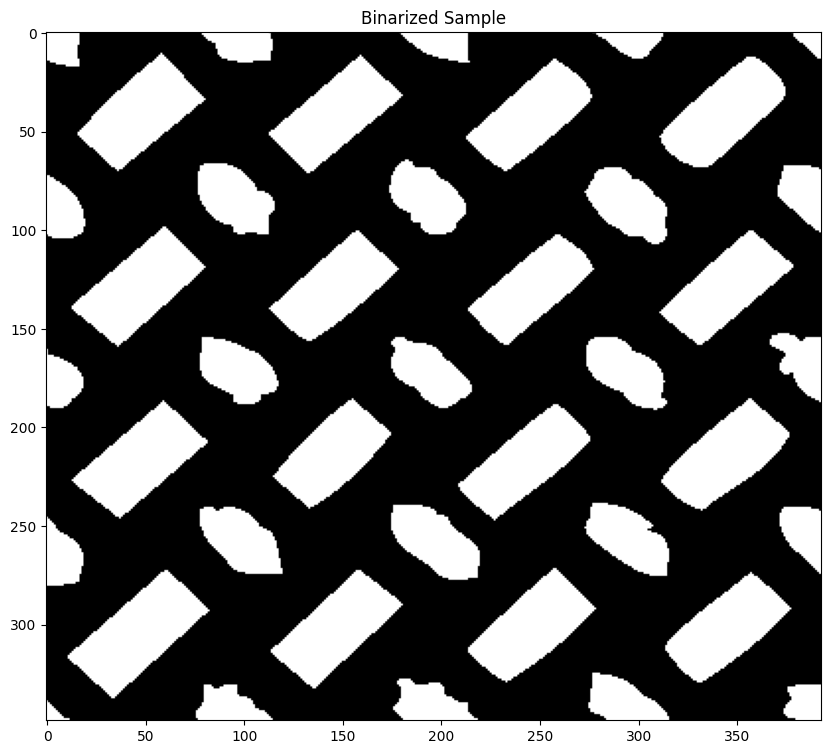

In [118]:
# memastikan binerisasi gambar

sample = cv2.imread("sampel-1_motif-utama.png")
sample_binary = binarize(sample)

height, width = sample_binary.shape

plt.figure(figsize=(10,10))
plt.imshow(sample_binary, cmap='gray')
plt.title("Binarized Sample")

np.unique(sample_binary)

## Umum

### Dinamika Ruang Kosong

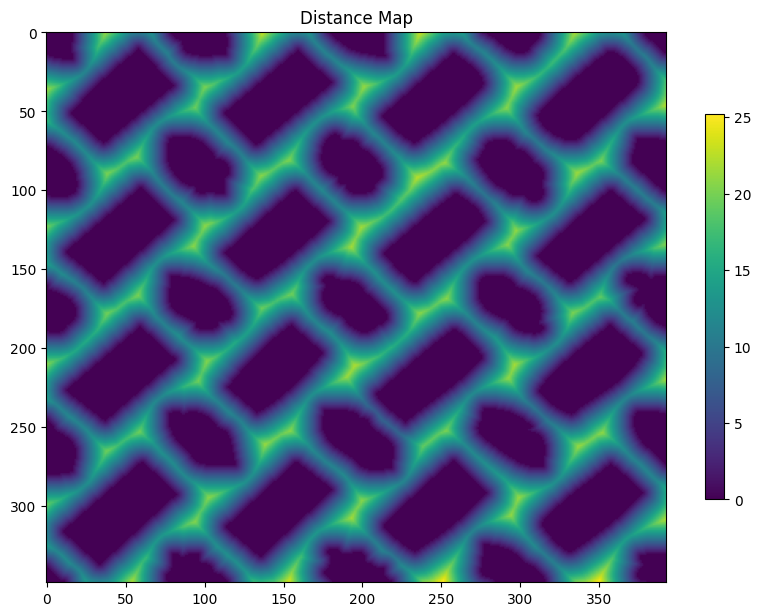

In [119]:
distance_map = cv2.distanceTransform(~sample_binary, cv2.DIST_L2, 5)

plt.figure(figsize=(10,10))
plt.imshow(distance_map)
plt.title("Distance Map")
plt.colorbar(shrink=0.5)
# plt.imshow(skeleton, cmap='gray', alpha=0.2)
# plt.axis('off')

DATA SUMMARY of [Void Distance List]:
Num     : 93025
Mean    : 8.7735
SD      : 4.9219
SD rel  : 56.10%
Median  : 8.4000
MAD     : 3.6000
MAD rel : 42.86%
Min     : 1.0000
Max     : 25.1814



{'num': 93025,
 'mean': 8.773526,
 'sd': 4.9218826,
 'median': 8.4,
 'mad': 3.6000004,
 'min': 1.0,
 'max': 25.181398}

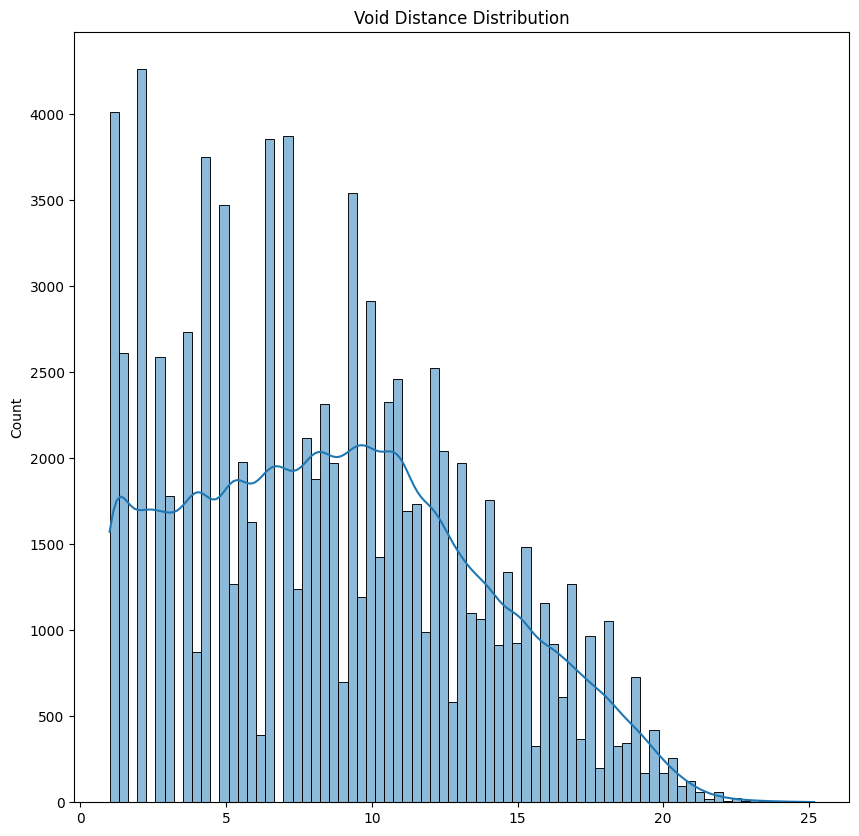

In [120]:
void_distance_list = distance_map.flatten()
void_distance_list = void_distance_list[void_distance_list > 0]

plt.figure(figsize=(10, 10))
sns.histplot(void_distance_list, kde=True)
plt.title("Void Distance Distribution")

summarizeData(void_distance_list, "Void Distance List")

In [121]:
area_occupancy = getAreaOccupancy(sample_binary)

print(f"Occupancy: {(area_occupancy*100):.2f}%")

Occupancy: 32.18%


array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41], dtype=int32)

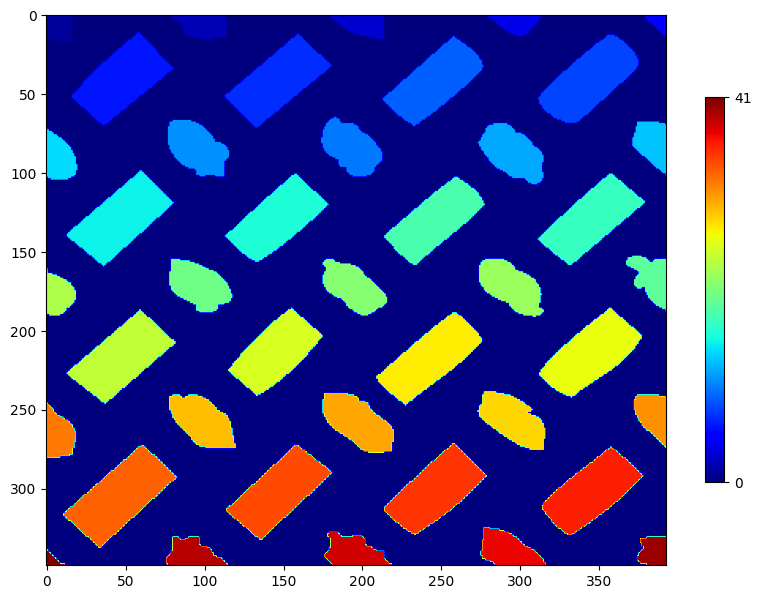

In [122]:
num_label, labeled_map, stats, centroids = cv2.connectedComponentsWithStats(sample_binary)

showLabeledMap(labeled_map)

## Varian Besar

41

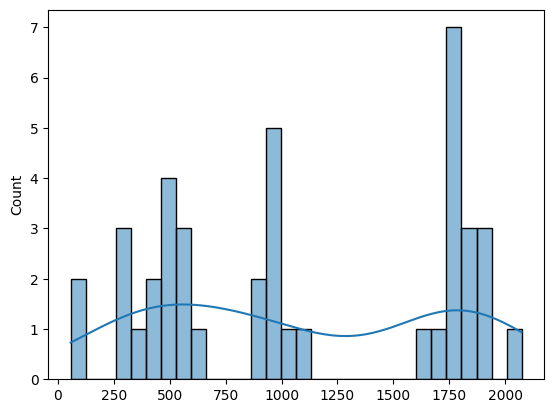

In [123]:
areas = stats[1:, cv2.CC_STAT_AREA]

sns.histplot(areas, kde=True, bins=30)

len(areas)

array([ 0,  6,  7,  8,  9, 15, 16, 17, 18, 24, 25, 26, 27, 33, 34, 35, 36],
      dtype=int32)

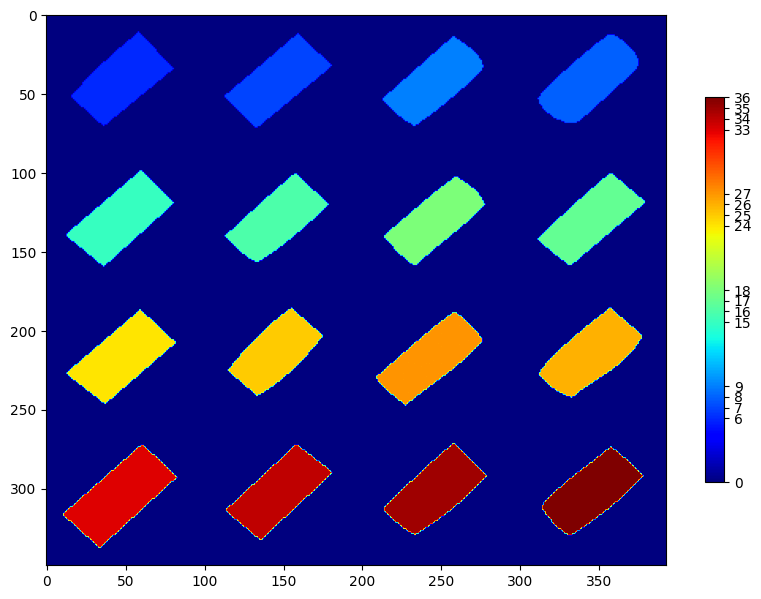

In [124]:
big_variant_mask = np.zeros(num_label, dtype='bool')

big_variant_mask[1:] = areas > 1500

big_variant_binary = big_variant_mask[labeled_map].astype(np.uint8) * 255
big_variant_map = big_variant_mask[labeled_map] * labeled_map
big_variant_labels = np.unique(big_variant_map)[1:]

showLabeledMap(big_variant_map, show_all=True)

### Jarak Antarpusat

<Axes: ylabel='Count'>

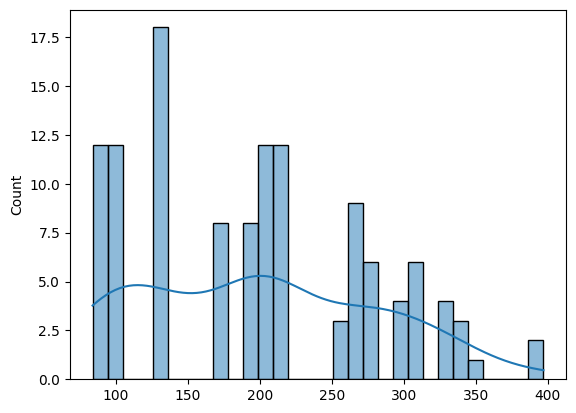

In [125]:
big_variant_center_distance_list = []
big_variant_orientation_list = []

for i in range(0, len(big_variant_labels)-1):
    for j in range(i+1, len(big_variant_labels)):
        center_distance = getNeighborCenterDistance(centroids, [big_variant_labels[i], big_variant_labels[j]])
        orientation = getNeighborOrientationDistance(centroids, [big_variant_labels[i], big_variant_labels[j]])
        big_variant_center_distance_list.append(center_distance)
        big_variant_orientation_list.append(np.degrees(orientation))

big_variant_center_distance_list = np.array(big_variant_center_distance_list)
big_variant_orientation_list = np.array(big_variant_orientation_list)

sns.histplot(big_variant_center_distance_list, kde=True, bins=30)

In [126]:
big_variant_orientation_list = big_variant_orientation_list[big_variant_center_distance_list < 110]
big_variant_center_distance_list = big_variant_center_distance_list[big_variant_center_distance_list < 110]

big_distance_vertical_list = big_variant_center_distance_list[big_variant_center_distance_list < 90]
big_distance_horizontal_list = big_variant_center_distance_list[big_variant_center_distance_list > 90]

len(big_variant_orientation_list)

24

In [127]:
distance_vertical_summary = summarizeData(big_distance_vertical_list, "Vertical Distances")
distance_horizontal_summary = summarizeData(big_distance_horizontal_list, "Horizontal Distances")

DATA SUMMARY of [Vertical Distances]:
Num     : 12
Mean    : 87.0064
SD      : 1.5092
SD rel  : 1.73%
Median  : 87.6883
MAD     : 0.4615
MAD rel : 0.53%
Min     : 83.8287
Max     : 88.3810

DATA SUMMARY of [Horizontal Distances]:
Num     : 12
Mean    : 99.0841
SD      : 1.1452
SD rel  : 1.16%
Median  : 98.8749
MAD     : 0.6910
MAD rel : 0.70%
Min     : 97.4798
Max     : 101.7753



Text(0.5, 1.0, 'Big Variant Orientation Placement')

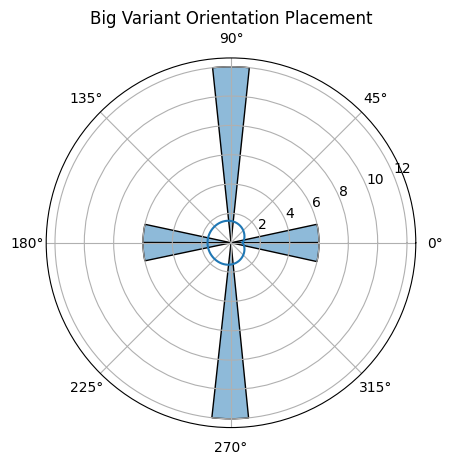

In [128]:
big_variant_orientation_repeated = np.concatenate((big_variant_orientation_list, big_variant_orientation_list + 180))

ax = plt.axes(projection='polar')
sns.histplot(big_variant_orientation_repeated / 180 * np.pi, ax=ax, kde=True, bins=30)

ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("Big Variant Orientation Placement")

### Kesebangunan & Kongruensi

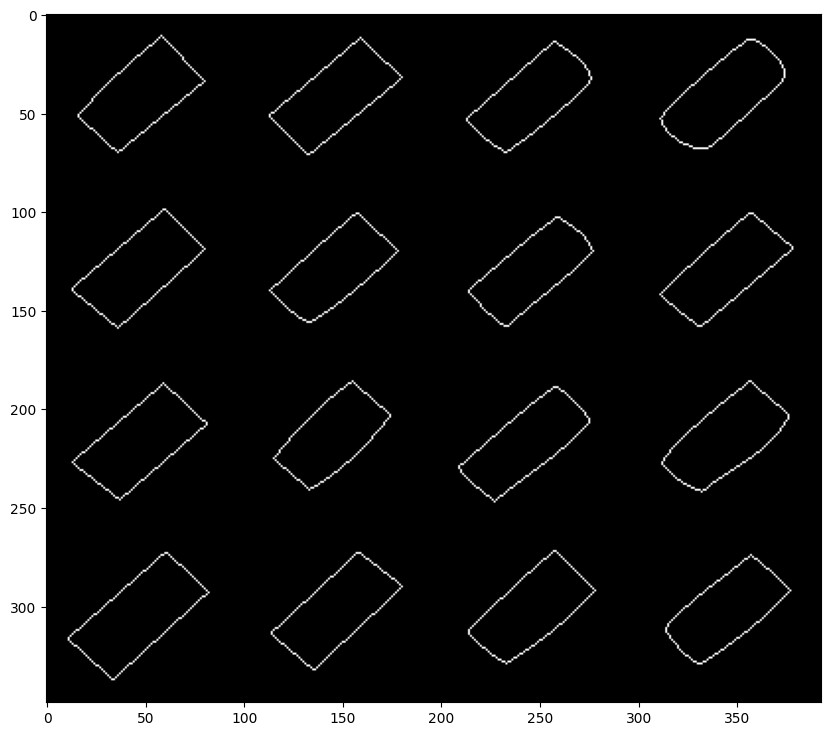

In [129]:
big_contours = extractContours(big_variant_binary)

# contour1 = np.squeeze(contours[0])
# interpolateCoordinates(standardizeContour(contour1))
big_contour_map = createContourMap(sample_binary.shape, big_contours)

plt.figure(figsize=(10, 10))
plt.imshow(big_contour_map, cmap='gray')

In [130]:
big_contours_interpolated = interpolateContours(big_contours, 100)
big_mean_shape, big_contours_rotated = processGPA(big_contours_interpolated)

2.977062866937347e-08


In [131]:
big_procrustes_distances = procrustesDistances(big_mean_shape, big_contours_rotated)
summarizeData(big_procrustes_distances, "Procrustes Analysis")

DATA SUMMARY of [Procrustes Analysis]:
Num     : 16
Mean    : 0.0333
SD      : 0.0100
SD rel  : 29.93%
Median  : 0.0308
MAD     : 0.0059
MAD rel : 19.16%
Min     : 0.0197
Max     : 0.0560



{'num': 16,
 'mean': 0.03334114781800646,
 'sd': 0.009979937306476951,
 'median': 0.030818847386406587,
 'mad': 0.005904932054142314,
 'min': 0.019731823464441384,
 'max': 0.05597748194953829}

In [132]:
big_contour_areas = contourAreas(big_contours)
summarizeData(np.sqrt(big_contour_areas), "Big Variant Rooted Areas")

DATA SUMMARY of [Big Variant Rooted Areas]:
Num     : 16
Mean    : 41.6624
SD      : 1.1282
SD rel  : 2.71%
Median  : 41.5842
MAD     : 0.6056
MAD rel : 1.46%
Min     : 39.6043
Max     : 44.7381



{'num': 16,
 'mean': 41.66243441052408,
 'sd': 1.1281883658233864,
 'median': 41.58422042886124,
 'mad': 0.6055702878275611,
 'min': 39.604292696625706,
 'max': 44.73812691653507}

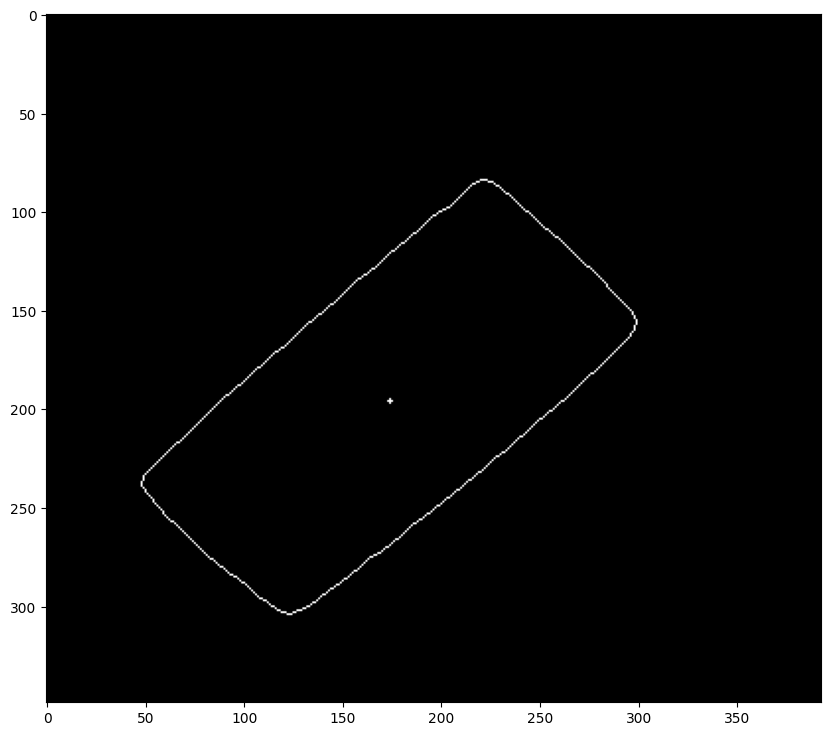

In [133]:
big_size_factor = 1000

big_mean_shape_binary = drawStandardizedContour(sample_binary.shape, big_mean_shape, big_size_factor)

plt.figure(figsize=(10, 10))
plt.imshow(big_mean_shape_binary, cmap='gray')

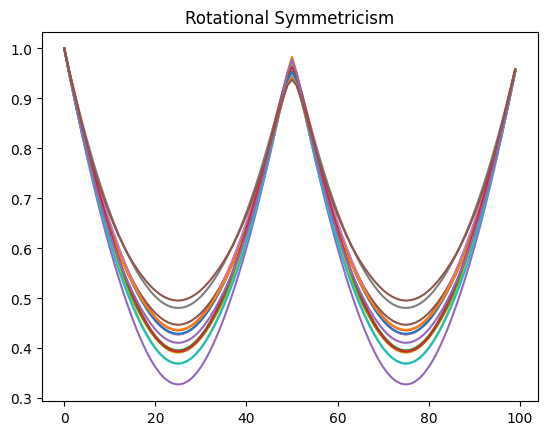

In [134]:
plt.title("Rotational Symmetricism")
for shape in big_contours_rotated:
    sns.lineplot(testRotationalSymmetry(shape))

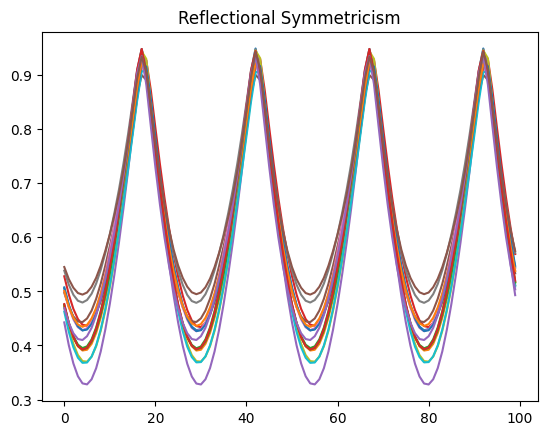

In [135]:
plt.title("Reflectional Symmetricism")
for shape in big_contours_rotated:
    sns.lineplot(testReflectionalSymmetry(shape))

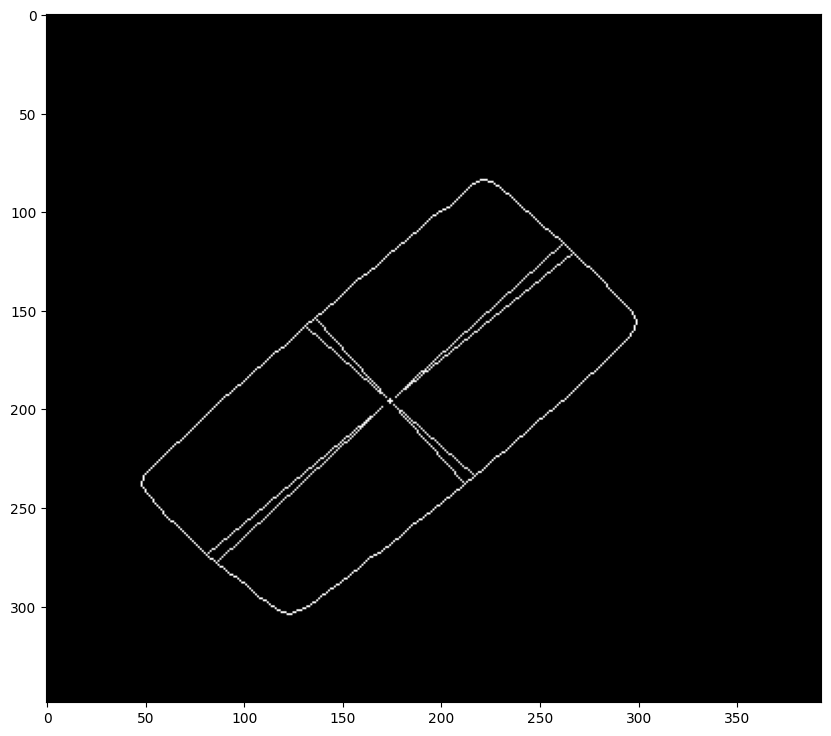

In [136]:
big_mean_shape_reflectional_symmetry = drawReflectionalSymmetryAxis(
    sample_binary.shape, big_mean_shape, big_size_factor, 
)

plt.figure(figsize=(10, 10))
plt.imshow(big_mean_shape_reflectional_symmetry, cmap='gray')

## Varian Kecil

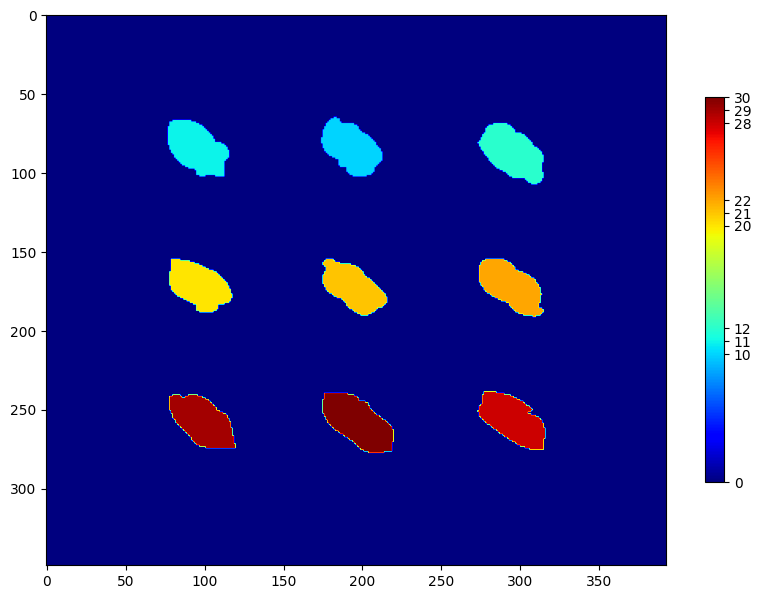

In [137]:
small_variant_mask = np.zeros(num_label, dtype='bool')

small_variant_mask[1:] = (areas > 700) & (areas < 1100)

small_variant_binary = small_variant_mask[labeled_map].astype(np.uint8) * 255
small_variant_map = small_variant_mask[labeled_map] * labeled_map
small_variant_labels = np.unique(small_variant_map)[1:]

plt.figure(figsize=(10, 10))
plt.imshow(small_variant_map, cmap="jet")
colorbar = plt.colorbar(shrink=0.5)
colorbar.set_ticks(np.unique(small_variant_map))

### Jarak Antarpusat

<Axes: ylabel='Count'>

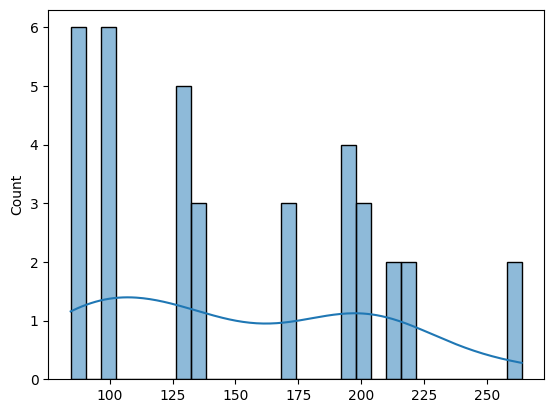

In [138]:
small_variant_center_distance_list = []
small_variant_orientation_list = []

for i in range(0, len(small_variant_labels)-1):
    for j in range(i+1, len(small_variant_labels)):
        center_distance = getNeighborCenterDistance(centroids, [small_variant_labels[i], small_variant_labels[j]])
        orientation = getNeighborOrientationDistance(centroids, [small_variant_labels[i], small_variant_labels[j]])
        small_variant_center_distance_list.append(center_distance)
        small_variant_orientation_list.append(np.degrees(orientation))

small_variant_center_distance_list = np.array(small_variant_center_distance_list)
small_variant_orientation_list = np.array(small_variant_orientation_list)

sns.histplot(small_variant_center_distance_list, kde=True, bins=30)

In [139]:
small_variant_orientation_list = small_variant_orientation_list[small_variant_center_distance_list < 120]
small_variant_center_distance_list = small_variant_center_distance_list[small_variant_center_distance_list < 120]

small_distance_vertical_list = small_variant_center_distance_list[small_variant_center_distance_list < 90]
small_distance_horizontal_list = small_variant_center_distance_list[small_variant_center_distance_list > 90]

len(small_variant_orientation_list)

12

In [140]:
small_distance_vertical_summary = summarizeData(small_distance_vertical_list, "Vertical Distances")
small_distance_horizontal_summary = summarizeData(small_distance_horizontal_list, "Horizontal Distances")

DATA SUMMARY of [Vertical Distances]:
Num     : 6
Mean    : 86.0651
SD      : 1.3877
SD rel  : 1.61%
Median  : 85.8786
MAD     : 1.2120
MAD rel : 1.41%
Min     : 84.5408
Max     : 88.4945

DATA SUMMARY of [Horizontal Distances]:
Num     : 6
Mean    : 98.9650
SD      : 1.6700
SD rel  : 1.69%
Median  : 98.2362
MAD     : 0.6862
MAD rel : 0.70%
Min     : 97.5205
Max     : 102.1911



Text(0.5, 1.0, 'Small Variant Orientation Placement')

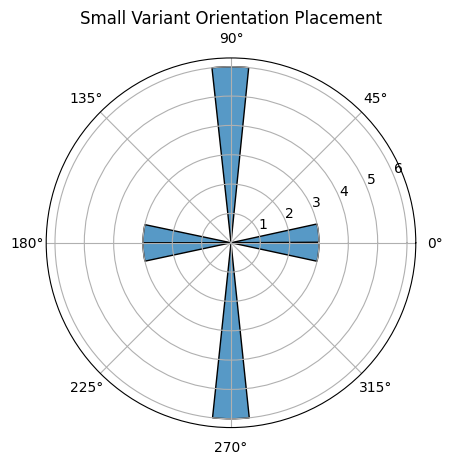

In [141]:
small_variant_orientation_repeated = np.concatenate((small_variant_orientation_list, small_variant_orientation_list + 180))

ax = plt.axes(projection='polar')
sns.histplot(small_variant_orientation_repeated / 180 * np.pi, ax=ax, bins=30)

ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("Small Variant Orientation Placement")

### Kesebangunan dan Kongruensi

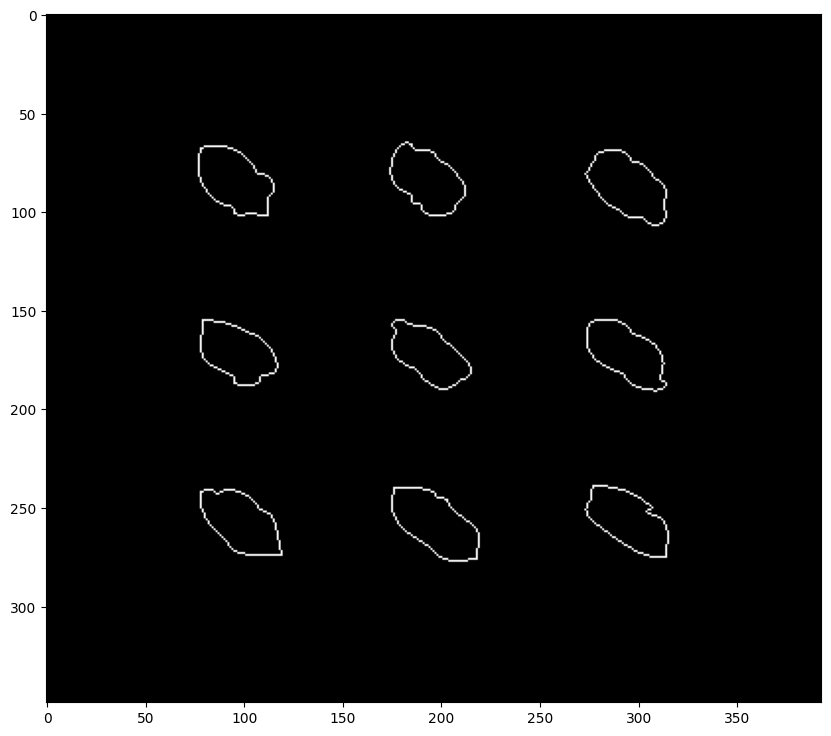

In [142]:
small_contours = extractContours(small_variant_binary)

# contour1 = np.squeeze(contours[0])
# interpolateCoordinates(standardizeContour(contour1))
small_contour_map = createContourMap(sample_binary.shape, small_contours)

plt.figure(figsize=(10, 10))
plt.imshow(small_contour_map, cmap='gray')

In [143]:
small_contours_interpolated = interpolateContours(small_contours, 100)
small_mean_shape, small_contours_rotated = processGPA(small_contours_interpolated)

4.364990858963822e-06


In [144]:
summarizeData(procrustesDistances(small_mean_shape, small_contours_rotated), "Procrustes Analysis")

DATA SUMMARY of [Procrustes Analysis]:
Num     : 9
Mean    : 0.0658
SD      : 0.0113
SD rel  : 17.22%
Median  : 0.0672
MAD     : 0.0076
MAD rel : 11.32%
Min     : 0.0430
Max     : 0.0850



{'num': 9,
 'mean': 0.06577895911240929,
 'sd': 0.011327373372265012,
 'median': 0.06717802393856401,
 'mad': 0.007604323961555984,
 'min': 0.042995603423481694,
 'max': 0.0850277602657788}

In [145]:
small_contour_areas = contourAreas(small_contours)
summarizeData(np.sqrt(small_contour_areas), "Small Variant Rooted Areas")

DATA SUMMARY of [Small Variant Rooted Areas]:
Num     : 9
Mean    : 30.2150
SD      : 0.9722
SD rel  : 3.22%
Median  : 30.2076
MAD     : 0.4083
MAD rel : 1.35%
Min     : 28.7489
Max     : 32.1870



{'num': 9,
 'mean': 30.214960023280128,
 'sd': 0.9721520871100302,
 'median': 30.20761493398643,
 'mad': 0.40828608248375176,
 'min': 28.7489130229301,
 'max': 32.18695387886216}

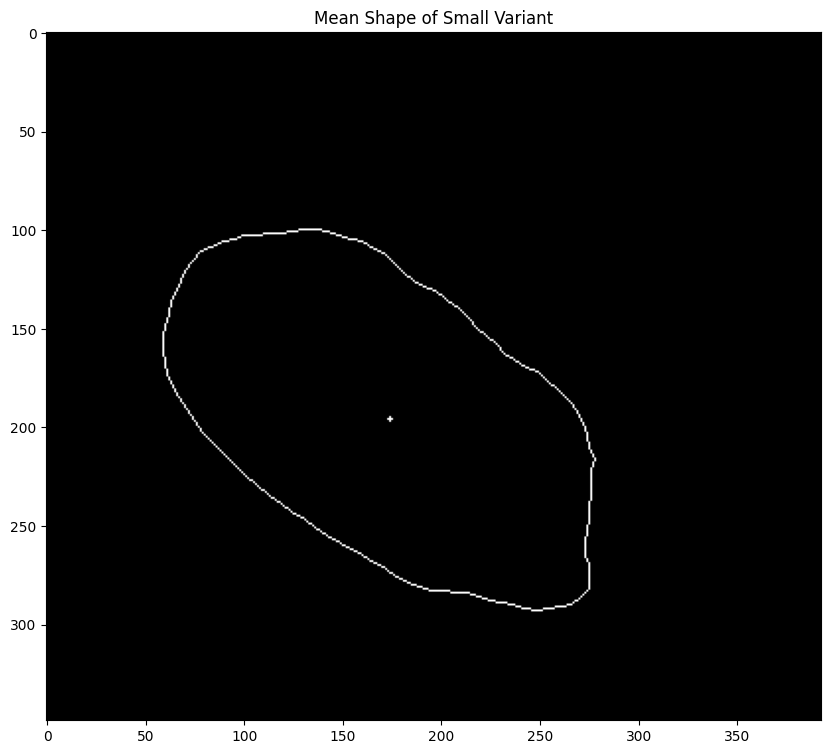

In [146]:
small_size_factor = 1000

small_mean_shape_binary = drawStandardizedContour(
    sample_binary.shape, small_mean_shape, small_size_factor
)

plt.figure(figsize=(10, 10))
plt.title("Mean Shape of Small Variant")
plt.imshow(small_mean_shape_binary, cmap='gray')

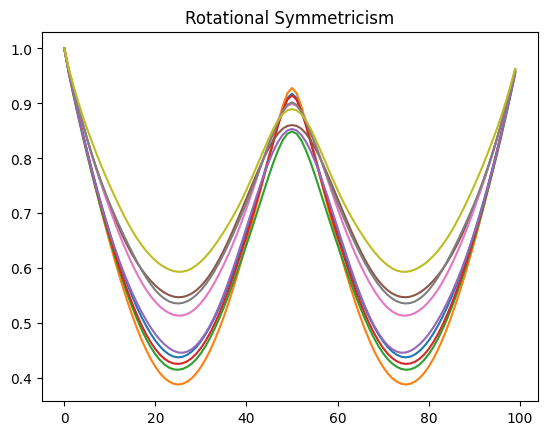

In [147]:
plt.title("Rotational Symmetricism")
for shape in small_contours_rotated:
    sns.lineplot(testRotationalSymmetry(shape))

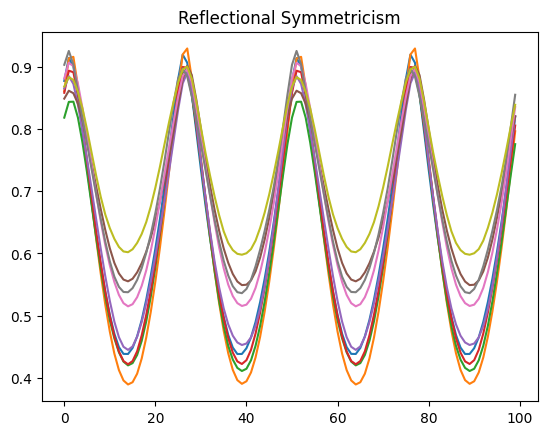

In [148]:
plt.title("Reflectional Symmetricism")
for shape in small_contours_rotated:
    sns.lineplot(testReflectionalSymmetry(shape))

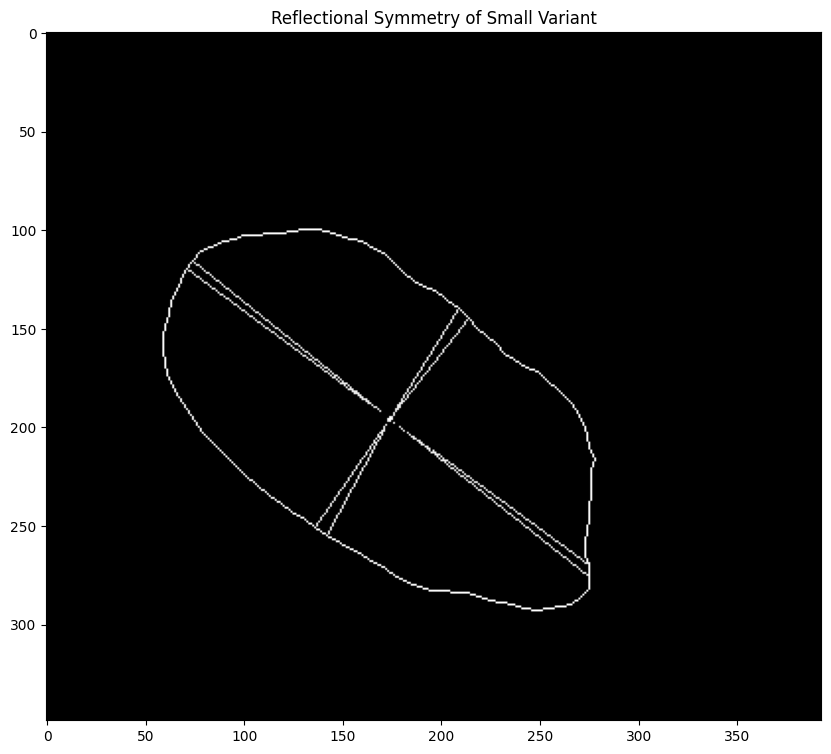

In [149]:
small_mean_shape_reflectional_symmetry = drawReflectionalSymmetryAxis(
    sample_binary.shape, small_mean_shape, small_size_factor
)

plt.figure(figsize=(10, 10))
plt.title("Reflectional Symmetry of Small Variant")
plt.imshow(small_mean_shape_reflectional_symmetry, cmap='gray')